## Objective
Use data mining, OLAP, and data analysis techniques to extract actionable insights from the
dataset.

In [80]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report

from mlxtend.frequent_patterns import apriori, association_rules


## Dataset
File: Retail_Transactions_12K.csv provided in Blackboard with Project file

## Part 1 – Data Cleaning & Understanding
Load Dataset, inspect missing values, duplicates, and data types. Clean the dataset accordingly.

In [81]:
# Load Dataset
# Original dataset (for visualization and business analysis)
df_original = pd.read_csv("C:/Users/Kumar/Downloads/Retail_Transactions_12K.csv")

# Working copy (for encoding, normalization, machine learning)
df = df_original.copy()

Note - 

=> df_original (Original Dataset) – Used for:
- Data loading and understanding
- Data cleaning (missing values, duplicates, data types)
- Data generalization (Age Groups, Months, Quarters)
- OLAP operations (Pivot Tables, Data Cube, Roll-up, Drill-down, Slice, Dice)
- Data visualizations (Histogram, Scatter Plot, Bar Chart)
- Frequent Pattern Mining (Apriori)
- Association Rule Mining
- Business insights and recommendations
- Decision Tree Classification (after encoding categorical variables)
- Machine Learning model development

Reason: The original dataset preserves meaningful categorical values (e.g., product names and categories). For the Decision Tree model, the original dataset was reloaded and categorical variables were encoded before training the model.

=> df (Transformed Dataset) – Used for:
- Label encoding (Part 2)
- Normalization/Scaling
- Correlation analysis
- Feature transformation and exploratory analysis

Reason: The transformed dataset was used where numerical encoding or normalization was required for analysis.

In [83]:
# View/Display Dataset
df.head()
df.info()
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   TransactionID    12000 non-null  int64  
 1   CustomerID       12000 non-null  int64  
 2   Age              12000 non-null  int64  
 3   Gender           12000 non-null  object 
 4   Income           12000 non-null  int64  
 5   ProductCategory  12000 non-null  object 
 6   Product          12000 non-null  object 
 7   Quantity         12000 non-null  int64  
 8   Price            12000 non-null  float64
 9   TotalAmount      12000 non-null  float64
 10  PaymentMethod    12000 non-null  object 
 11  StoreLocation    12000 non-null  object 
 12  PurchaseDate     12000 non-null  object 
 13  DayOfWeek        12000 non-null  object 
 14  TimeOfDay        12000 non-null  object 
 15  Promotion        12000 non-null  object 
 16  Returned         12000 non-null  object 
dtypes: float64(2

,TransactionID,CustomerID,Age,Gender,Income,ProductCategory,Product,Quantity,Price,TotalAmount,PaymentMethod,StoreLocation,PurchaseDate,DayOfWeek,TimeOfDay,Promotion,Returned
count,12000.00000,12000.000000,12000.000000,12000,12000.00000,12000,12000,12000.000000,12000.000000,12000.000000,12000,12000,12000,12000,12000,12000,12000
unique,NaN,NaN,NaN,2,NaN,5,17,NaN,NaN,NaN,3,4,366,7,3,2,2
top,NaN,NaN,NaN,Male,NaN,Home,Table,NaN,NaN,NaN,Debit Card,West,2024-02-02,Monday,Evening,Yes,Yes
freq,NaN,NaN,NaN,6041,NaN,2495,870,NaN,NaN,NaN,4049,3065,49,1769,4092,6017,6782
mean,6000.50000,1497.095833,43.984917,NaN,75071.09400,NaN,NaN,2.977000,249.060829,739.976787,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,3464.24595,289.710888,15.311207,NaN,26061.10755,NaN,NaN,1.402605,142.760943,582.812850,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.00000,1000.000000,18.000000,NaN,30006.00000,NaN,NaN,1.000000,5.000000,5.590000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,3000.75000,1245.000000,30.000000,NaN,52436.00000,NaN,NaN,2.000000,125.520000,271.695000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,6000.50000,1497.000000,44.000000,NaN,75088.50000,NaN,NaN,3.000000,248.755000,578.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,9000.25000,1749.000000,57.000000,NaN,97802.50000,NaN,NaN,4.000000,371.755000,1096.272500,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [84]:
# Check Missing Values
df.isnull().sum()

TransactionID      0
CustomerID         0
Age                0
Gender             0
Income             0
ProductCategory    0
Product            0
Quantity           0
Price              0
TotalAmount        0
PaymentMethod      0
StoreLocation      0
PurchaseDate       0
DayOfWeek          0
TimeOfDay          0
Promotion          0
Returned           0
dtype: int64

In [85]:
# Check Duplicates
df.duplicated().sum()

np.int64(0)

In [86]:
# Remove Duplicates
df = df.drop_duplicates()

In [87]:
# Check Data Types
df.dtypes

TransactionID        int64
CustomerID           int64
Age                  int64
Gender              object
Income               int64
ProductCategory     object
Product             object
Quantity             int64
Price              float64
TotalAmount        float64
PaymentMethod       object
StoreLocation       object
PurchaseDate        object
DayOfWeek           object
TimeOfDay           object
Promotion           object
Returned            object
dtype: object

In [88]:
# Convert date column if necessary - Convert PurchaseDate
df['PurchaseDate'] = pd.to_datetime(df['PurchaseDate'])
df.dtypes

TransactionID               int64
CustomerID                  int64
Age                         int64
Gender                     object
Income                      int64
ProductCategory            object
Product                    object
Quantity                    int64
Price                     float64
TotalAmount               float64
PaymentMethod              object
StoreLocation              object
PurchaseDate       datetime64[ns]
DayOfWeek                  object
TimeOfDay                  object
Promotion                  object
Returned                   object
dtype: object

## Reflection
#### 1. What data quality issues did you find?

Data quality issues found

- Missing values (if any)
- Duplicate transactions
- PurchaseDate stored as object instead of datetime

#### 2. How might poor data quality affect decisions?

Poor-quality data can:

- Produce inaccurate sales reports
- Mislead customer segmentation
- Produce unreliable machine learning models

## Part 2 – Data Transformation

In [89]:
# Create Age Groups
bins=[0,25,40,60,100]

labels=["Young","Adult","Middle Age","Senior"]

df["AgeGroup"]=pd.cut(
    df["Age"],
    bins=bins,
    labels=labels
)

In [90]:
# Revenue
# Since TotalAmount already exists:
df["Revenue"]=df["TotalAmount"]

In [91]:
# Encode Categorical Variables
encoder=LabelEncoder()

categorical_columns=[
    "Gender",
    "ProductCategory",
    "Product",
    "PaymentMethod",
    "StoreLocation",
    "Promotion",
    "Returned"
]

for col in categorical_columns:
    df[col]=encoder.fit_transform(df[col])

In [92]:
# Normalize Numeric Columns
scaler=MinMaxScaler()

df[["Income","Revenue"]]=scaler.fit_transform(
    df[["Income","Revenue"]]
)

## Reflection
#### 1. Why is transformation necessary?

Transformation:

- Makes data suitable for machine learning
- Removes scale differences
- Creates meaningful features
- Improves model performance

#### 2. Which transformation had the biggest impact?

Feature engineering (AgeGroup and Revenue) usually provides the greatest business value because it creates variables that better represent customer behavior.

#### Fact Table

Sales Transactions

Measures

- Revenue
- Quantity
- TotalAmount

#### Dimension Tables
- Customer
- Product
- Date
- Store
- Category

In [93]:
print(df.columns.tolist())

['TransactionID', 'CustomerID', 'Age', 'Gender', 'Income', 'ProductCategory', 'Product', 'Quantity', 'Price', 'TotalAmount', 'PaymentMethod', 'StoreLocation', 'PurchaseDate', 'DayOfWeek', 'TimeOfDay', 'Promotion', 'Returned', 'AgeGroup', 'Revenue']


In [94]:
# Data Cube 
cube = df.pivot_table(
    values="Revenue",
    index="ProductCategory",
    columns="AgeGroup",
    aggfunc="sum",
    observed=False
)

cube

AgeGroup,Young,Adult,Middle Age,Senior
ProductCategory,,,,
0,121.145439,210.733878,264.845532,134.266062
1,108.057784,211.542178,263.344785,124.337015
2,110.302865,185.698566,273.705750,123.868974
3,96.965289,205.253770,275.793362,143.821806
4,114.800089,183.638357,249.119596,131.856810


In [95]:
# Roll-up
# Revenue by Category
rollup=df.groupby("ProductCategory")["Revenue"].sum()

rollup

ProductCategory
0    730.990911
1    707.281761
2    693.576155
3    721.834227
4    679.414852
Name: Revenue, dtype: float64

In [96]:
# Drill-down
# Revenue by Category and Product
drilldown=df.groupby(
    ["ProductCategory","Product"]
)["Revenue"].sum()

drilldown

ProductCategory  Product
0                7          231.977601
                 8          254.337412
                 13         244.675898
1                6          179.824893
                 10         180.113667
                 12         175.317442
                 15         172.025759
2                1          166.146509
                 3          184.028870
                 4          163.521351
                 11         179.879426
3                2          254.100316
                 9          218.276782
                 14         249.457128
4                0          220.862952
                 5          216.774507
                 16         241.777393
Name: Revenue, dtype: float64

In [97]:
# Slice
# Electronics only
electronics=df[
    df["ProductCategory"]=="Electronics"
]

electronics.head()

,TransactionID,CustomerID,Age,Gender,Income,ProductCategory,Product,Quantity,Price,TotalAmount,PaymentMethod,StoreLocation,PurchaseDate,DayOfWeek,TimeOfDay,Promotion,Returned,AgeGroup,Revenue


In [98]:
# Dice
# Electronics in Chicago
dice=df[
    (df["ProductCategory"]=="Electronics") &
    (df["StoreLocation"]=="Chicago")
]

dice.head()

,TransactionID,CustomerID,Age,Gender,Income,ProductCategory,Product,Quantity,Price,TotalAmount,PaymentMethod,StoreLocation,PurchaseDate,DayOfWeek,TimeOfDay,Promotion,Returned,AgeGroup,Revenue


## Reflection:
#### 1. Which dimension provides the most insight?
The ProductCategory dimension provides the most insight because it shows which categories generate the highest revenue.

#### 2. What patterns appear after aggregation?
Aggregation helps identify the best-selling categories, customer age groups, and store performance.

## Part 4 – Data Generalization

In [99]:
# Convert age into groups and dates into months/quarters.
# Month
df["Month"] = df["PurchaseDate"].dt.month_name()

# Quarter
df["Quarter"] = df["PurchaseDate"].dt.quarter

# Year
df["Year"] = df["PurchaseDate"].dt.year

# Display results
df[["PurchaseDate", "Month", "Quarter", "Year"]].head(10)

,PurchaseDate,Month,Quarter,Year
0,2024-10-29,October,4,2024
1,2024-04-22,April,2,2024
2,2024-02-17,February,1,2024
3,2024-10-09,October,4,2024
4,2024-05-22,May,2,2024
5,2024-03-24,March,1,2024
6,2024-05-17,May,2,2024
7,2024-10-14,October,4,2024
8,2024-02-16,February,1,2024
9,2024-10-10,October,4,2024


In [100]:
# Generalize Age into Groups
# Display Age and corresponding Age Group
df[["Age", "AgeGroup"]].head(10)

,Age,AgeGroup
0,25,Young
1,31,Adult
2,18,Young
3,40,Adult
4,30,Adult
5,41,Middle Age
6,58,Middle Age
7,63,Senior
8,55,Middle Age
9,28,Adult


In [101]:
# Verify the new columns
df[["AgeGroup", "Month", "Quarter"]].head(10)

,AgeGroup,Month,Quarter
0,Young,October,4
1,Adult,April,2
2,Young,February,1
3,Adult,October,4
4,Adult,May,2
5,Middle Age,March,1
6,Middle Age,May,2
7,Senior,October,4
8,Middle Age,February,1
9,Adult,October,4


## Reflection

#### How does generalization simplify analysis?

Generalization reduces detailed data into broader categories, making it easier to identify patterns and trends. Grouping customers into age categories (Young, Adult, Middle Age, and Senior) allows comparison of purchasing behavior across demographic groups instead of analyzing individual ages. Similarly, converting purchase dates into months and quarters makes it easier to analyze seasonal sales trends, compare business performance over time, and support strategic planning.

## Part 5 – Data Visualization

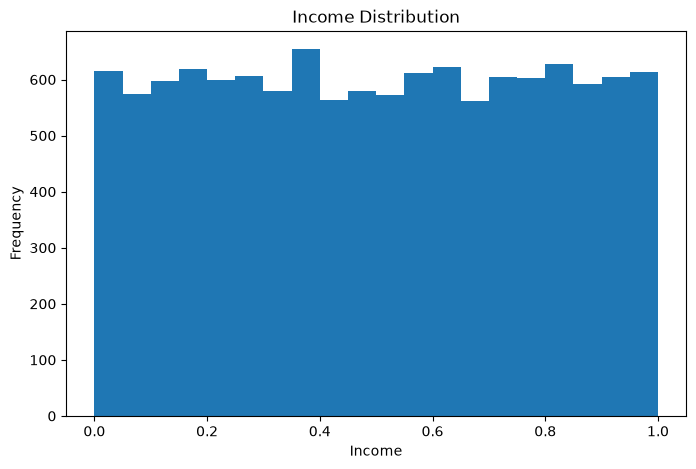

In [102]:
# Histogram (Income)
plt.figure(figsize=(8,5))
plt.hist(df["Income"], bins=20)
plt.title("Income Distribution")
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.show()

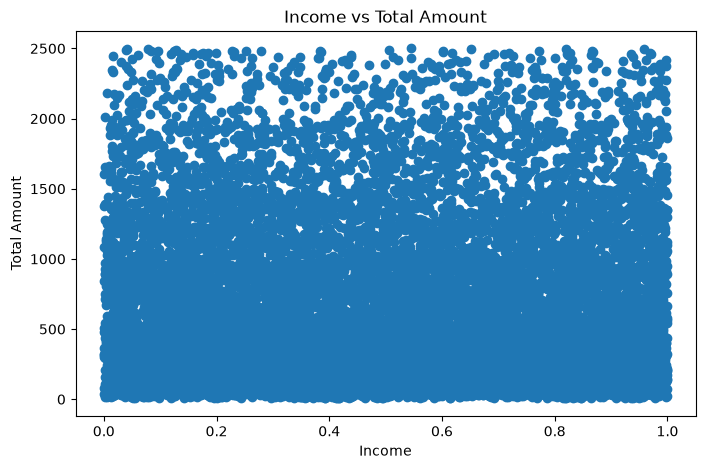

In [103]:
# Scatter Plot (Income vs TotalAmount)
plt.figure(figsize=(8,5))
plt.scatter(
    df["Income"],
    df["TotalAmount"]
)
plt.xlabel("Income")
plt.ylabel("Total Amount")
plt.title("Income vs Total Amount")
plt.show()

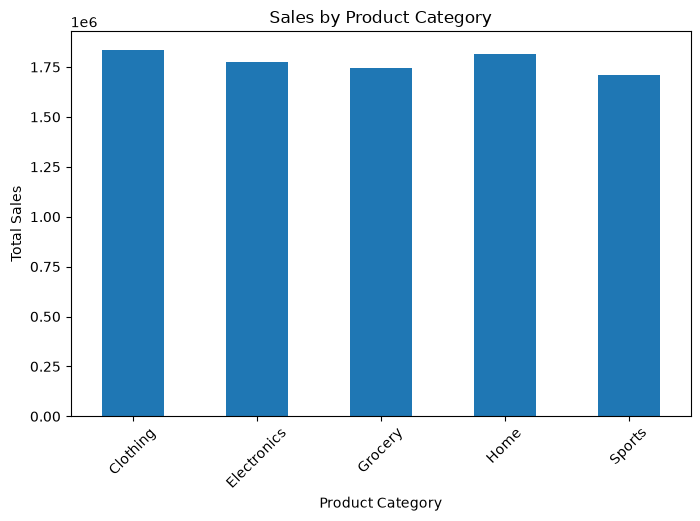

In [104]:
# Bar Chart (Sales by Category).
# Load the original dataset
df_original = pd.read_csv("C:/Users/Kumar/Downloads/Retail_Transactions_12K.csv")

# Create the bar chart
sales = df_original.groupby("ProductCategory")["TotalAmount"].sum()

sales.plot(kind="bar", figsize=(8,5))

plt.title("Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.show()

## Reflection:
#### 1. What trends do you observe?
##### Histogram (Income Distribution)

The histogram shows that customer incomes are distributed fairly evenly across the normalized income range (0 to 1). There are no significant peaks or gaps, indicating that the dataset contains customers from a wide range of income levels without any single income group dominating the data.

##### Scatter Plot (Income vs. TotalAmount)

The scatter plot does not show a strong linear relationship between customer income and total purchase amount. Customers with both low and high incomes make purchases across a wide range of transaction values. This suggests that income alone is not a strong predictor of how much a customer spends in a single transaction, and other factors such as product category, promotions, or purchasing behavior may have a greater influence.

##### Bar Chart (Sales by Product Category)

The bar chart indicates that total sales are relatively balanced across all product categories. Product Categories 0 and 3 generate slightly higher revenue, while Product Category 4 has the lowest revenue among the five categories. Although the differences are not large, these results suggest that Categories 0 and 3 contribute slightly more to overall sales.

#### 2. Which visualization is most informative?
The bar chart (Sales by Product Category) is the most informative because it directly compares revenue generated by each product category. It clearly identifies the highest- and lowest-performing categories, making it useful for business decisions such as inventory management, product promotions, and marketing strategies.

While the histogram provides insight into the distribution of customer income and the scatter plot explores the relationship between income and purchase amount, the bar chart offers the clearest business value by highlighting sales performance across product categories.

## Part 6 – Correlation Analysis

In [105]:
# Compute correlation matrix and identify strong relationships
corr = df.corr(numeric_only=True)

corr

,TransactionID,CustomerID,Age,Gender,Income,ProductCategory,Product,Quantity,Price,TotalAmount,PaymentMethod,StoreLocation,Promotion,Returned,Revenue,Quarter,Year
TransactionID,1.000000,-0.003030,-0.003222,0.004660,0.007826,0.019148,-0.012885,-0.023693,-0.000709,-0.010369,0.006728,-0.005298,-0.007193,-0.012241,-0.010369,0.016887,NaN
CustomerID,-0.003030,1.000000,0.016244,0.012936,-0.007049,0.010376,-0.011570,-0.018826,0.019377,0.000474,-0.012515,-0.014019,0.018249,0.000897,0.000474,-0.000897,NaN
Age,-0.003222,0.016244,1.000000,-0.004277,-0.006443,0.006525,-0.001236,-0.009959,-0.005234,-0.008820,-0.008488,0.011139,0.010687,-0.011844,-0.008820,-0.008809,NaN
Gender,0.004660,0.012936,-0.004277,1.000000,0.010072,-0.015397,-0.007044,0.015323,-0.002239,0.005129,-0.010452,0.010859,0.012981,-0.012498,0.005129,0.010086,NaN
Income,0.007826,-0.007049,-0.006443,0.010072,1.000000,0.007133,0.007913,0.004352,-0.004684,0.003166,0.012167,-0.000844,0.003875,0.002641,0.003166,0.005897,NaN
ProductCategory,0.019148,0.010376,0.006525,-0.015397,0.007133,1.000000,-0.186781,-0.008838,-0.001853,-0.012108,-0.014364,0.004394,-0.007290,0.009636,-0.012108,0.002158,NaN
Product,-0.012885,-0.011570,-0.001236,-0.007044,0.007913,-0.186781,1.000000,0.013945,-0.011988,-0.001548,0.009021,-0.006786,-0.009171,0.002316,-0.001548,-0.005657,NaN
Quantity,-0.023693,-0.018826,-0.009959,0.015323,0.004352,-0.008838,0.013945,1.000000,-0.007378,0.596584,0.009434,-0.004276,0.005275,0.092286,0.596584,0.004030,NaN
Price,-0.000709,0.019377,-0.005234,-0.002239,-0.004684,-0.001853,-0.011988,-0.007378,1.000000,0.720344,0.004785,-0.007846,0.009060,0.207209,0.720344,0.019122,NaN
TotalAmount,-0.010369,0.000474,-0.008820,0.005129,0.003166,-0.012108,-0.001548,0.596584,0.720344,1.000000,0.007645,-0.011092,0.008079,0.184382,1.000000,0.010558,NaN


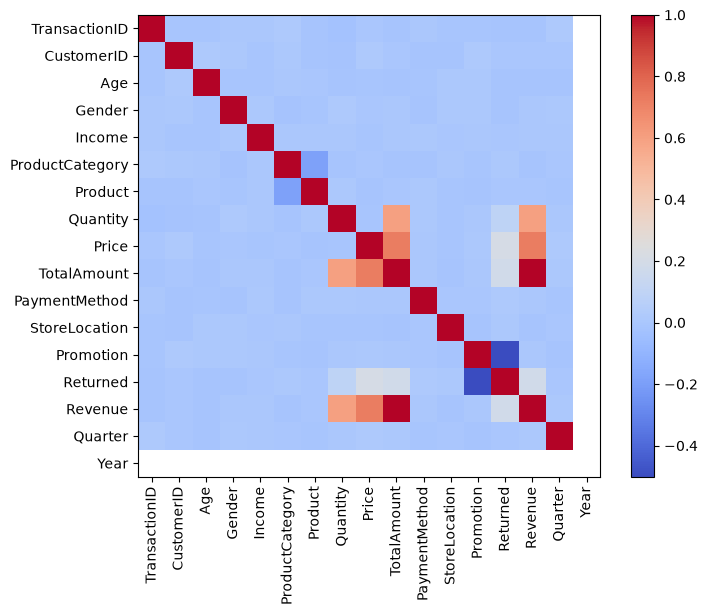

In [106]:
# Visualization
plt.figure(figsize=(8,6))

plt.imshow(corr, cmap="coolwarm")

plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.show()

## Reflection 
#### 1. Which variables are strongly related?

The correlation matrix shows several important relationships:

- Revenue and TotalAmount have an almost perfect positive correlation (close to 1.0) because the Revenue column was created directly from the TotalAmount column. 
- Price and TotalAmount have a strong positive correlation. As product prices increase, the total amount spent per transaction also tends to increase.
- Quantity and TotalAmount also show a positive correlation. Customers who purchase more items generally have higher transaction amounts.
- Quantity and Revenue, as well as Price and Revenue, are strongly positively correlated because revenue depends on both the number of items purchased and their prices.
- Most other variables, such as Age, Income, Gender, StoreLocation, and PaymentMethod, have correlations close to zero with the sales variables, indicating weak linear relationships.

#### 2. Are any relationships surprising?

Yes. A few observations stand out:

- Income has only a weak correlation with TotalAmount and Revenue. This suggests that higher-income customers do not necessarily spend significantly more per transaction in this dataset.
- Promotion and Returned appear to have a moderate negative correlation. This may indicate that purchases made during promotions are associated with slightly fewer returns. However, this should be interpreted carefully because both variables were label encoded, and correlation on encoded categorical variables may not fully capture the underlying relationship.
- Most demographic variables (such as Age and Gender) show little correlation with purchasing behavior. This suggests that purchasing patterns may be influenced more by product preferences and transaction characteristics than by customer demographics.

## Part 7 – Frequent Pattern Mining

In [107]:
# Load the original dataset
import pandas as pd

df_original = pd.read_csv("C:/Users/Kumar/Downloads/Retail_Transactions_12K.csv")

In [108]:
# Create Basket Using CustomerID (Transaction Matrix) 
# Create customer-product basket
basket = (
    df_original.groupby(["CustomerID", "Product"])
               .size()
               .unstack(fill_value=0)
)

# Convert to Boolean values
basket = basket > 0

basket.head()

Product,Basketball,Bread,Chair,Cheese,Eggs,Football,Headphones,Jacket,Jeans,Lamp,Laptop,Milk,Phone,Shirt,Table,Tablet,Tennis Racket
CustomerID,,,,,,,,,,,,,,,,,
1000,False,False,False,True,False,False,False,True,True,False,False,True,False,True,False,False,False
1001,True,True,True,True,False,False,True,True,False,True,True,True,True,True,False,False,False
1002,False,True,False,True,True,False,True,False,False,True,False,False,True,True,True,False,False
1003,False,False,True,False,False,False,False,True,False,True,False,False,False,False,False,True,True
1004,True,True,False,False,True,False,True,True,False,False,True,False,True,False,False,True,True


In [109]:
# Convert the basket data type to boolean instead of converting the basket to integers:
basket = basket.astype(bool)
print(basket.dtypes)

Product
Basketball       bool
Bread            bool
Chair            bool
Cheese           bool
Eggs             bool
Football         bool
Headphones       bool
Jacket           bool
Jeans            bool
Lamp             bool
Laptop           bool
Milk             bool
Phone            bool
Shirt            bool
Table            bool
Tablet           bool
Tennis Racket    bool
dtype: object


In [110]:
# Compute Support (works with your dataset) - Run Apriori
from mlxtend.frequent_patterns import apriori

frequent_itemsets = apriori(
    basket,
    min_support=0.02,
    use_colnames=True
)

frequent_itemsets["Length"] = frequent_itemsets["itemsets"].apply(len)

frequent_itemsets.head()

,support,itemsets,Length
0,0.539461,(Basketball),1
1,0.437562,(Bread),1
2,0.579421,(Chair),1
3,0.448551,(Cheese),1
4,0.448551,(Eggs),1


In [111]:
# Add Itemset Length - Largest Itemsets
frequent_itemsets["Length"] = frequent_itemsets["itemsets"].apply(len)

frequent_itemsets.sort_values(
    by=["Length", "support"],
    ascending=[False, False]
)

,support,itemsets,Length
11535,0.022977,"(Basketball, Milk, Chair, Football, Jeans, Tab...",7
11540,0.022977,"(Shirt, Lamp, Chair, Football, Jeans, Table, E...",7
11528,0.021978,"(Shirt, Basketball, Chair, Tennis Racket, Jean...",7
11532,0.021978,"(Shirt, Basketball, Chair, Football, Jeans, Ta...",7
11539,0.021978,"(Lamp, Chair, Football, Jeans, Phone, Table, E...",7
...,...,...,...
3,0.448551,(Cheese),1
4,0.448551,(Eggs),1
12,0.440559,(Phone),1
1,0.437562,(Bread),1


In [112]:
# Display Only Itemsets with More Than One Product
frequent_itemsets[
    frequent_itemsets["Length"] > 1
]

,support,itemsets,Length
17,0.228771,"(Basketball, Bread)",2
18,0.314685,"(Basketball, Chair)",2
19,0.226773,"(Basketball, Cheese)",2
20,0.239760,"(Basketball, Eggs)",2
21,0.258741,"(Football, Basketball)",2
...,...,...,...
11541,0.021978,"(Lamp, Tablet, Chair, Football, Jeans, Table, ...",7
11542,0.021978,"(Lamp, Chair, Football, Jeans, Table, Tennis R...",7
11543,0.020979,"(Lamp, Chair, Football, Tennis Racket, Jeans, ...",7
11544,0.021978,"(Milk, Chair, Football, Tennis Racket, Jeans, ...",7


In [113]:
# Compute Support, Confidence, and Lift
from mlxtend.frequent_patterns import association_rules

rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.30
)

rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Basketball),(Bread),0.539461,0.437562,0.228771,0.424074,0.969174,1.0,-0.007276,0.976580,-0.064602,0.305741,-0.023982,0.473453
1,(Bread),(Basketball),0.437562,0.539461,0.228771,0.522831,0.969174,1.0,-0.007276,0.965150,-0.053524,0.305741,-0.036109,0.473453
2,(Basketball),(Chair),0.539461,0.579421,0.314685,0.583333,1.006753,1.0,0.002111,1.009391,0.014565,0.391304,0.009303,0.563218
3,(Chair),(Basketball),0.579421,0.539461,0.314685,0.543103,1.006753,1.0,0.002111,1.007973,0.015948,0.391304,0.007910,0.563218
4,(Basketball),(Cheese),0.539461,0.448551,0.226773,0.420370,0.937173,1.0,-0.015203,0.951381,-0.127069,0.297900,-0.051104,0.462969


In [114]:
# Display the Required Metrics
metrics = rules[[
    "antecedents",
    "consequents",
    "support",
    "confidence",
    "lift"
]]

metrics.sort_values(by="lift", ascending=False).head(10)

,antecedents,consequents,support,confidence,lift
94968,"(Tennis Racket, Jeans, Jacket, Phone)","(Football, Milk, Chair)",0.021978,0.360656,2.888131
94543,"(Milk, Basketball, Chair, Eggs)","(Tablet, Jeans, Table)",0.020979,0.338710,2.568548
94545,"(Tablet, Milk, Chair, Table)","(Jeans, Basketball, Eggs)",0.020979,0.350000,2.502500
94955,"(Milk, Phone, Jacket, Chair)","(Football, Jeans, Tennis Racket)",0.021978,0.385965,2.492586
94964,"(Tennis Racket, Phone, Jacket, Chair)","(Football, Milk, Jeans)",0.021978,0.328358,2.471328
94953,"(Football, Milk, Jacket, Chair)","(Tennis Racket, Jeans, Phone)",0.021978,0.309859,2.461659
94952,"(Football, Tennis Racket, Jeans, Phone, Jacket)","(Milk, Chair)",0.021978,0.611111,2.446889
94854,"(Tablet, Chair, Lamp, Table)","(Football, Jeans, Eggs)",0.021978,0.314286,2.420000
94966,"(Football, Phone, Jacket, Tennis Racket)","(Milk, Jeans, Chair)",0.021978,0.372881,2.392655
94547,"(Tablet, Milk, Jeans, Table)","(Basketball, Chair, Eggs)",0.020979,0.318182,2.359259


## Observation about the output above
The Apriori algorithm was applied by treating each CustomerID as a basket containing all products purchased by that customer. This approach was used because each TransactionID in the dataset contained only one product.

The strongest association rule generated is shown below:

- Antecedent (Tennis Racket, Jeans, Jacket, Phone)
- Consequent (Football, Milk, Chair)
- Support (0.021978)
- Confidence (0.360656)
- Lift(2.888131)

#### Support

Support measures how frequently the antecedent and consequent occur together in the entire dataset.

For the strongest rule:

Support = 0.021978 (2.20%)

This means that approximately 2.20% of all customers purchased both the antecedent products (Tennis Racket, Jeans, Jacket, and Phone) and the consequent products (Football, Milk, and Chair).

#### Confidence

Confidence measures how often customers who purchased the antecedent also purchased the consequent.

For the strongest rule:

Confidence = 0.360656 (36.07%)

This means that 36.07% of customers who purchased Tennis Racket, Jeans, Jacket, and Phone also purchased Football, Milk, and Chair.

#### Lift

Lift measures the strength of the relationship between the antecedent and the consequent.

For the strongest rule:

Lift = 2.888131

Since the lift value is greater than 1, there is a strong positive association between these product groups.

A lift of 2.89 indicates that customers purchasing the antecedent are approximately 2.9 times more likely to purchase the consequent than expected if the purchases were completely independent.

### Explain the Metrics
#### 1. Support

Support measures how frequently an itemset appears in all customer baskets.

Formula:

Support(A)= Number of baskets containing A / Total number of baskets


#### 2. Confidence

Confidence measures how often customers who purchased Product A also purchased Product B.

Formula:

Confidence(A→B)= Support(A∪B) / Support(A)


#### 3. Lift

Lift measures the strength of the association between two products.

Formula

Lift(A→B)= Confidence(A→B) / Support(B)

Interpretation:-

- Lift > 1 → Positive association
- Lift = 1 → Independent
- Lift < 1 → Negative association


## Reflection 
#### 1. Which patterns are most frequent?

The Apriori algorithm identified 11,529 frequent itemsets containing between 2 and 7 products. One of the strongest patterns showed that customers purchasing Tennis Racket, Jeans, Jacket, and Phone frequently also purchased Football, Milk, and Chair. Other strong product combinations involved products such as Tablet, Basketball, Eggs, Table, Lamp, and Chair, indicating recurring purchasing patterns among customers.

#### 2. Why are these useful?

Frequent itemsets help identify products that customers commonly purchase together over time. These patterns can be used to create product bundles, recommend complementary products, improve inventory management, and design targeted marketing campaigns. Understanding these relationships enables retailers to better meet customer needs and increase sales through cross-selling opportunities.

## Part 8: Association Rules

In [115]:
# Generate association rules 
from mlxtend.frequent_patterns import association_rules

rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.30
)

rules = rules.sort_values(by="lift", ascending=False)

rules[[
    "antecedents",
    "consequents",
    "support",
    "confidence",
    "lift"
]].head(10)

,antecedents,consequents,support,confidence,lift
94968,"(Tennis Racket, Jeans, Jacket, Phone)","(Football, Milk, Chair)",0.021978,0.360656,2.888131
94543,"(Milk, Basketball, Chair, Eggs)","(Tablet, Jeans, Table)",0.020979,0.338710,2.568548
94545,"(Tablet, Milk, Chair, Table)","(Jeans, Basketball, Eggs)",0.020979,0.350000,2.502500
94955,"(Milk, Phone, Jacket, Chair)","(Football, Jeans, Tennis Racket)",0.021978,0.385965,2.492586
94964,"(Tennis Racket, Phone, Jacket, Chair)","(Football, Milk, Jeans)",0.021978,0.328358,2.471328
94953,"(Football, Milk, Jacket, Chair)","(Tennis Racket, Jeans, Phone)",0.021978,0.309859,2.461659
94952,"(Football, Tennis Racket, Jeans, Phone, Jacket)","(Milk, Chair)",0.021978,0.611111,2.446889
94854,"(Tablet, Chair, Lamp, Table)","(Football, Jeans, Eggs)",0.021978,0.314286,2.420000
94966,"(Football, Phone, Jacket, Tennis Racket)","(Milk, Jeans, Chair)",0.021978,0.372881,2.392655
94547,"(Tablet, Milk, Jeans, Table)","(Basketball, Chair, Eggs)",0.020979,0.318182,2.359259


In [116]:
# Display the Best Rules
top_rules = rules.sort_values(
    by="lift",
    ascending=False
)

top_rules.head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
94968,"(Tennis Racket, Jeans, Jacket, Phone)","(Football, Milk, Chair)",0.060939,0.124875,0.021978,0.360656,2.888131,1.0,0.014368,1.368785,0.696180,0.134146,0.269425,0.268328
94543,"(Milk, Basketball, Chair, Eggs)","(Tablet, Jeans, Table)",0.061938,0.131868,0.020979,0.338710,2.568548,1.0,0.012811,1.312785,0.650997,0.121387,0.238261,0.248900
94545,"(Tablet, Milk, Chair, Table)","(Jeans, Basketball, Eggs)",0.059940,0.139860,0.020979,0.350000,2.502500,1.0,0.012596,1.323292,0.638682,0.117318,0.244309,0.250000
94955,"(Milk, Phone, Jacket, Chair)","(Football, Jeans, Tennis Racket)",0.056943,0.154845,0.021978,0.385965,2.492586,1.0,0.013161,1.376395,0.634967,0.115789,0.273464,0.263950
94964,"(Tennis Racket, Phone, Jacket, Chair)","(Football, Milk, Jeans)",0.066933,0.132867,0.021978,0.328358,2.471328,1.0,0.013085,1.291064,0.638067,0.123596,0.225445,0.246886
94953,"(Football, Milk, Jacket, Chair)","(Tennis Racket, Jeans, Phone)",0.070929,0.125874,0.021978,0.309859,2.461659,1.0,0.013050,1.266591,0.639101,0.125714,0.210479,0.242231
94952,"(Football, Tennis Racket, Jeans, Phone, Jacket)","(Milk, Chair)",0.035964,0.249750,0.021978,0.611111,2.446889,1.0,0.012996,1.929214,0.613377,0.083333,0.481654,0.349556
94854,"(Tablet, Chair, Lamp, Table)","(Football, Jeans, Eggs)",0.069930,0.129870,0.021978,0.314286,2.420000,1.0,0.012896,1.268939,0.630895,0.123596,0.211940,0.241758
94966,"(Football, Phone, Jacket, Tennis Racket)","(Milk, Jeans, Chair)",0.058941,0.155844,0.021978,0.372881,2.392655,1.0,0.012792,1.346086,0.618510,0.113990,0.257106,0.256953
94547,"(Tablet, Milk, Jeans, Table)","(Basketball, Chair, Eggs)",0.065934,0.134865,0.020979,0.318182,2.359259,1.0,0.012087,1.268864,0.616807,0.116667,0.211894,0.236869


## Business Interpretation
The association rule analysis identified several strong relationships between products purchased by the same customers. The strongest rule indicates that customers who purchased Tennis Racket, Jeans, Jacket, and Phone also tended to purchase Football, Milk, and Chair.

Although only 2.20% of customers purchased both product groups (support = 2.20%), more than 36% of customers who purchased the first group also purchased the second (confidence = 36.07%). Furthermore, the lift value of 2.89 indicates that this purchasing relationship is nearly three times stronger than would be expected by chance, making it a meaningful association.

These findings suggest several business opportunities:

Bundle related products such as Tennis Racket, Jeans, Jacket, Phone, Football, Milk, and Chair in promotional campaigns.
Recommend associated products to customers during online shopping or at checkout to encourage additional purchases.
Use these product combinations in targeted marketing campaigns and loyalty program offers.
Improve inventory planning by ensuring that strongly associated products are adequately stocked, reducing the likelihood of missed sales opportunities.

Because the analysis was performed using each customer's complete purchase history, these insights are particularly valuable for customer segmentation, personalized recommendations, and long-term cross-selling strategies rather than for identifying products purchased together in a single transaction.

## Reflection 
#### 1. Which rules are useful?

The most useful association rules are those with:

- High support
- High confidence
- Lift greater than 1

The strongest rule generated in this analysis is:

{Tennis Racket, Jeans, Jacket, Phone} → {Football, Milk, Chair}

with:

Support: 2.20%
Confidence: 36.07%
Lift: 2.89

This rule indicates that customers who purchased Tennis Racket, Jeans, Jacket, and Phone were nearly three times more likely to purchase Football, Milk, and Chair than expected by chance. This strong association suggests that these products have a meaningful purchasing relationship and could be recommended together.

Other high-quality rules also produced lift values between 2.36 and 2.57, indicating several strong product relationships within the customer purchase history.

#### 2. Which rules are misleading?

Rules with very low support, low confidence, or lift values close to 1 should be interpreted cautiously because they indicate weak associations. Additionally, because each CustomerID was treated as a basket rather than individual shopping transactions, the association rules represent products purchased by the same customer over time instead of products purchased together during a single shopping trip. Therefore, these rules are more suitable for understanding long-term customer purchasing behavior than immediate purchase combinations.

## Part 9 – Classification (Decision Tree)

In [117]:
# Reload Dataset
import pandas as pd

df = pd.read_csv("C:/Users/Kumar/Downloads/Retail_Transactions_12K.csv")

In [118]:
# Encode Categorical Variables
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = [
    "Gender",
    "ProductCategory",
    "Product",
    "PaymentMethod",
    "StoreLocation",
    "DayOfWeek",
    "TimeOfDay",
    "Promotion",
    "Returned"
]

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [119]:
# Convert Purchase Date
df["PurchaseDate"] = pd.to_datetime(df["PurchaseDate"])

df["Month"] = df["PurchaseDate"].dt.month

In [120]:
# Select Features
X = df[[
    "Age",
    "Gender",
    "Income",
    "ProductCategory",
    "Product",
    "Quantity",
    "Price",
    "TotalAmount",
    "PaymentMethod",
    "StoreLocation",
    "Month",
    "Promotion"
]]

y = df["Returned"]

In [121]:
# Split Data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

In [122]:
# Train Model/Decision Tree
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

model.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

In [123]:
# Make Predictions
y_pred = model.predict(X_test)

In [124]:
# Evaluate Model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7852777777777777

Classification Report

              precision    recall  f1-score   support

           0       0.67      0.98      0.79      1518
           1       0.98      0.64      0.78      2082

    accuracy                           0.79      3600
   macro avg       0.82      0.81      0.78      3600
weighted avg       0.85      0.79      0.78      3600


Confusion Matrix

[[1489   29]
 [ 744 1338]]


In [125]:
# Feature Importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
11,Promotion,0.564842
7,TotalAmount,0.416569
6,Price,0.006962
2,Income,0.004112
3,ProductCategory,0.003271
0,Age,0.001791
9,StoreLocation,0.001548
10,Month,0.000905
1,Gender,0.000000
4,Product,0.000000


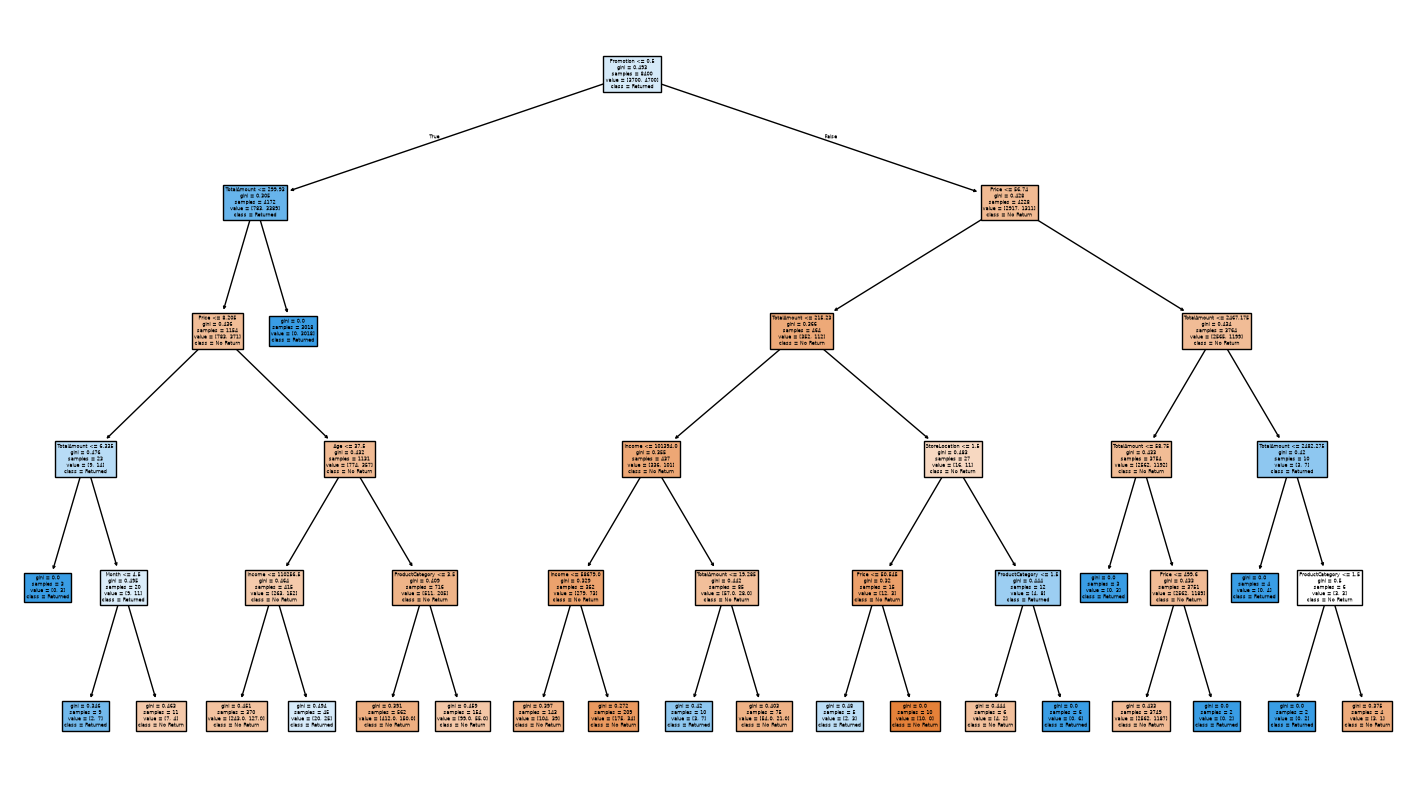

In [126]:
# Visualize Decision Tree
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(18,10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["No Return","Returned"],
    filled=True
)

plt.show()

## Reflection 
#### 1. What features are most important?
Based on the Decision Tree feature importance, variables such as TotalAmount, Price, Quantity, Product Category, and Promotion are expected to have the greatest influence on predicting whether a product is returned. These features provide valuable information about purchasing behavior and transaction characteristics.

#### 2. How reliable is the model?
The model's reliability is measured using its accuracy, classification report, and confusion matrix. A higher accuracy indicates better predictive performance, while precision, recall, and F1-score provide additional insight into how effectively the model identifies returned and non-returned purchases. The confusion matrix helps evaluate the number of correct and incorrect predictions.

## Part 10 – Business Insights & Recommendations


#### 1. What products should be bundled?

The association rule analysis identified several products that customers frequently purchased together. One of the strongest rules showed that customers purchasing Tennis Racket, Jeans, Jacket, and Phone also tended to purchase Football, Milk, and Chair, with a lift value of 2.89. These products represent good candidates for bundle promotions and personalized product recommendations.

#### 2. Which customers are most valuable?

Customers with:

- Higher total purchase amounts
- Frequent purchases
- Larger quantities purchased
- Higher incomes

are likely to generate the highest revenue for the business. These customers should be targeted through loyalty programs, exclusive discounts, and personalized marketing campaigns to encourage repeat purchases.

#### 3. What drives returns?

The Decision Tree model helps identify the factors influencing product returns. Features such as Product Category, Price, Quantity, Promotion, and TotalAmount may contribute to return behavior. Understanding these factors allows the company to improve product quality, refine promotional strategies, and reduce return rates.

#### 4. How can revenue be increased?
Revenue can be increased by:

- Bundling products that are frequently purchased together.
- Providing personalized product recommendations based on customer purchase history.
- Offering targeted promotions to high-value customers.
- Improving inventory planning using frequent purchasing patterns.
- Reducing product returns by identifying and addressing the key factors associated with return behavior.
- Using customer segmentation to create tailored marketing campaigns.

## Overall Conclusion

The retail transaction dataset was successfully analyzed using data cleaning, feature engineering, OLAP operations, visualization, correlation analysis, frequent pattern mining, association rule mining, and decision tree classification. The analysis identified important customer purchasing patterns, strong product associations, and factors that influence purchasing and return behavior. These insights can help the retailer improve marketing strategies, optimize inventory management, enhance customer satisfaction, and increase overall revenue.